In [46]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.base import TransformerMixin, BaseEstimator, RegressorMixin

In [ ]:
class DataLoader:
    def __init__(self, countries, max_count = (0, 5)):
        self.countries = countries
        self.max_count = max_count

    def get_dataset(self, folder_path):
        data = pd.DataFrame()
        for country in self.countries:
            for count in range(*self.max_count):
                path = folder_path + f"{country}_{count}.csv"
                try:
                    df = pd.read_csv(path)
                    data = pd.concat([data, df])
                except Exception as e:
                    print(f"Нет директории {path}: {e}")
        data["war_status"] = data["war_status"].astype(int)
        return data
    
    def prepare_target(self, data):
        y = data["gdp"].bfill().ffill()
        return np.log1p(y)

In [49]:
loader = DataLoader(["ENG", "USA", "RUS", "AUS"], (1, 6))
data = loader.get_dataset("data/")

Нет директории data/ENG_4.csv: [Errno 2] No such file or directory: 'data/ENG_4.csv'
Нет директории data/ENG_5.csv: [Errno 2] No such file or directory: 'data/ENG_5.csv'
Нет директории data/USA_2.csv: Error tokenizing data. C error: Expected 42 fields in line 141, saw 83

Нет директории data/USA_4.csv: [Errno 2] No such file or directory: 'data/USA_4.csv'
Нет директории data/USA_5.csv: [Errno 2] No such file or directory: 'data/USA_5.csv'
Нет директории data/RUS_4.csv: [Errno 2] No such file or directory: 'data/RUS_4.csv'
Нет директории data/RUS_5.csv: [Errno 2] No such file or directory: 'data/RUS_5.csv'
Нет директории data/AUS_4.csv: [Errno 2] No such file or directory: 'data/AUS_4.csv'
Нет директории data/AUS_5.csv: [Errno 2] No such file or directory: 'data/AUS_5.csv'


In [50]:
cat_cols = ["goverement", "most_popular_party", "war_status"]
num_cols = ["population", "money_activity", "industrial_level", "subside_percent", "rentability", "subside_pct", "diversification", "gold_income",\
             "country_savings", "bank_savings", "population_savings", "money_mass", "all_employemenent", "all_free_work_places", "fabric_worker_salary",\
             "capitalist_salary", "literacy", "military_budget", "naval_budget", "army_innov", "naval_innov", "country_size", "population_per_reg",\
             "rich_tax", "middle_tax", "poor_tax", "prom_innov", "comm_innov"]
all_cols = cat_cols + num_cols

In [51]:
class DataProcessor(BaseEstimator, TransformerMixin):
    def __init__(self, num_cols):
        self.num_cols = num_cols

    def fit(self, X, y=None):
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()
        X["gdp"] = X["gdp"].bfill().ffill()
        for col in self.num_cols:
            X[col] = X[col].fillna(0).astype(int)
        return X
    
class DataSelector(BaseEstimator, TransformerMixin):
    def __init__(self, all_cols):
        self.all_cols = all_cols
    
    def fit(self, X, y = None):
        return self
    
    def transform(self, X):
        return X[self.all_cols]

In [52]:
pipe = Pipeline([
    ("Data_prepare", DataProcessor(num_cols)),
    ("Data_select", DataSelector(all_cols)),
    ("Model", CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        loss_function="RMSE",
        l2_leaf_reg=5.0,
        depth=6,
        verbose=100,
        cat_features=cat_cols
    ))
])

In [53]:
train, val = train_test_split(data, test_size = 0.1, random_state=42, shuffle=True)
y = loader.prepare_target(train)
y_val = loader.prepare_target(val)

In [54]:
y

69         0.0
15      9667.0
27    -12557.0
101    25806.0
35    -11636.0
        ...   
12     -5200.0
36       885.0
22        62.0
61     -2715.0
8       1576.0
Name: gdp, Length: 1384, dtype: float64

In [55]:
pipe.fit(train, y)

0:	learn: 8136.3662212	total: 31ms	remaining: 30.9s
100:	learn: 5518.5205768	total: 2.37s	remaining: 21.1s
200:	learn: 5310.5162699	total: 4.85s	remaining: 19.3s
300:	learn: 5047.5438372	total: 7.27s	remaining: 16.9s
400:	learn: 4749.0539639	total: 9.72s	remaining: 14.5s
500:	learn: 4476.3876136	total: 12.1s	remaining: 12s
600:	learn: 4238.5652718	total: 14.4s	remaining: 9.53s
700:	learn: 4026.1237663	total: 16.7s	remaining: 7.11s
800:	learn: 3851.1686511	total: 19s	remaining: 4.72s
900:	learn: 3667.2611375	total: 21.3s	remaining: 2.34s
999:	learn: 3470.7858509	total: 23.6s	remaining: 0us


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Data_prepare', ...), ('Data_select', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,num_cols,"['population', 'money_activity', ...]"
,all_cols,"['goverement', 'most_popular_party', ...]"


In [56]:
test_loader = DataLoader(["FRA"], (1, 3))
test = test_loader.get_dataset("data/")
y_test = loader.prepare_target(test)

In [57]:
prediction = pipe.predict(test)

In [58]:
print(root_mean_squared_error(np.expm1(y_test), np.expm1(prediction)))

c:\Users\User\Documents\parser\vic2-save\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\User\AppData\Local\Temp\ipykernel_15908\1311957682.py:1: RuntimeWarning: overflow encountered in expm1
  print(root_mean_squared_error(np.expm1(y_test), np.expm1(prediction)))


ValueError: Input contains infinity or a value too large for dtype('float64').

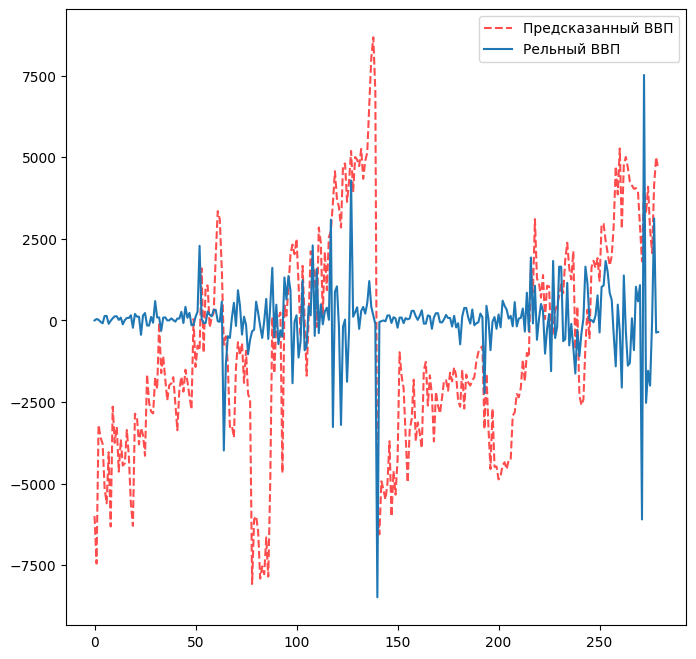

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.plot(prediction, "r--", label = "Предсказанный ВВП", alpha = 0.7)
plt.plot(y_test.to_numpy(), label = "Рельный ВВП") 
plt.legend()
plt.show()

In [ ]:
import shap

c:\Users\User\Documents\parser\vic2-save\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
test_ = DataProcessor(num_cols).fit_transform(test)
X_test = DataSelector(all_cols).fit_transform(test_)

(280, 42) == (280, 42)


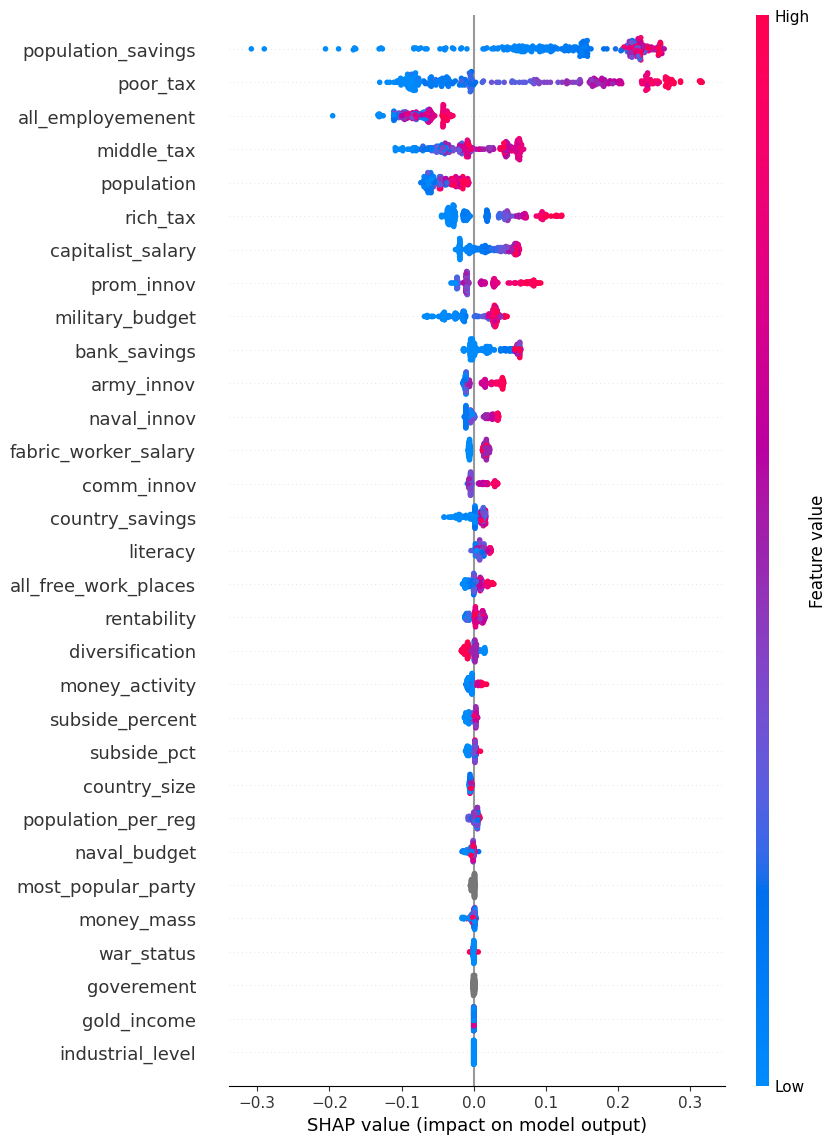

In [ ]:
model = pipe.named_steps["Model"]
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values, 100)